# Кластерный анализ посетителей фитнес-клуба

**Цель:** выявить поведенческие сегменты клиентов 
для персонализации маркетинга и снижения оттока.

**Данные:** Gym Members Exercise Dataset, 973 записи, 15 признаков.

## Содержание
- [1. Загрузка данных](#1-загрузка-данных)
- [2. EDA](#2-eda)
- [3. Preprocessing](#3-preprocessing)
- [4. Кластеризация](#4-кластеризация)
- [4.1. Кластеризация c учетом типа тренировки](#41-кластеризация-c-учетом-типа-тренировки)
- [4.2. Кластеризация без учета типа тренировки](#42-кластеризация-без-учета-типа-тренировки)
- [4.3. Визуализация](#43-визуализация)
- [5. Выводы](#5-выводы)

In [107]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Загрузка данных

In [108]:
df = pd.read_csv('../data/gym_members_exercise_tracking.csv')
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## 2. EDA

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [110]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


Проверка пропусков

In [111]:
df.isna().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

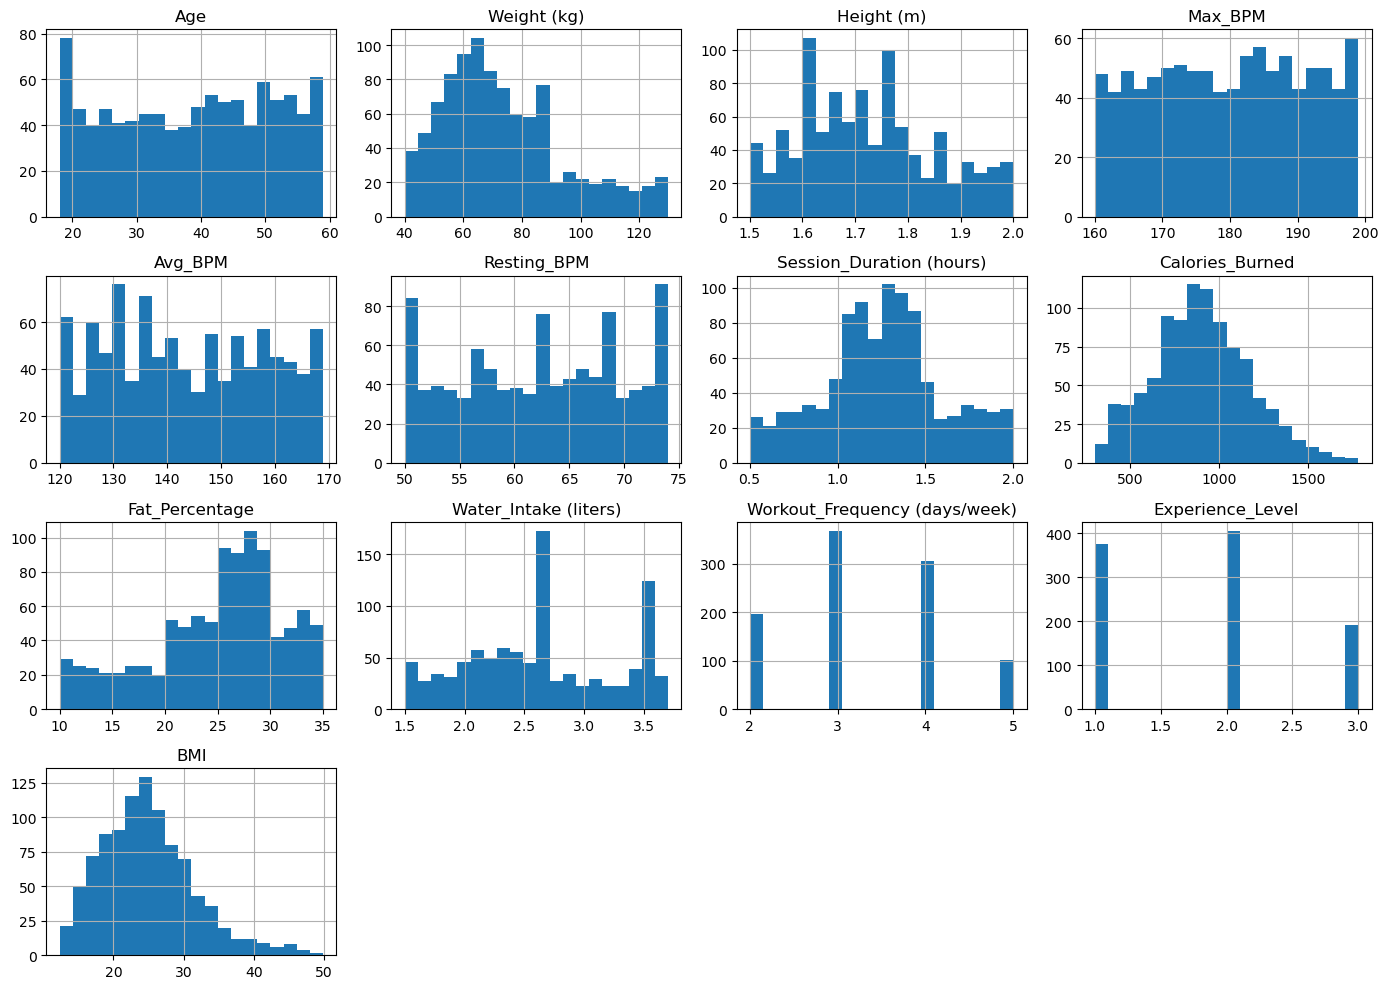

In [112]:
df.hist(figsize = (14, 10), bins = 20)
plt.tight_layout()
plt.show()

In [113]:
print(df['Gender'].value_counts())
print(df['Workout_Type'].value_counts())
print(df['Experience_Level'].value_counts())

Gender
Male      511
Female    462
Name: count, dtype: int64
Workout_Type
Strength    258
Cardio      255
Yoga        239
HIIT        221
Name: count, dtype: int64
Experience_Level
2    406
1    376
3    191
Name: count, dtype: int64


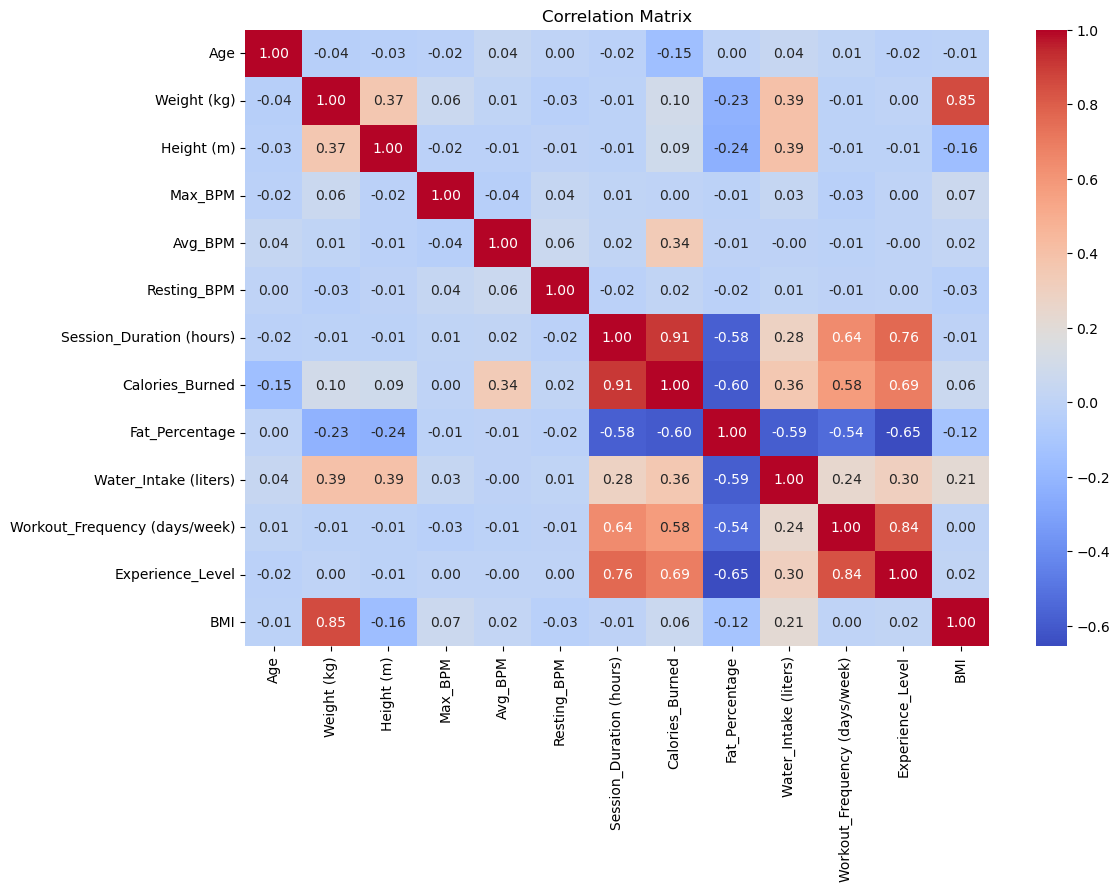

In [114]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [115]:
df.corr(numeric_only=True)

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
Age,1.000000,-0.036340,-0.027837,-0.017073,0.035969,0.004354,-0.019912,-0.154679,0.002370,0.041528,0.008055,-0.018676,-0.013691
Weight (kg),-0.036340,1.000000,0.365321,0.057061,0.009717,-0.032138,-0.013666,0.095443,-0.225512,0.394276,-0.011769,0.003379,0.853158
Height (m),-0.027837,0.365321,1.000000,-0.017660,-0.014776,-0.005090,-0.010206,0.086348,-0.235521,0.393533,-0.011270,-0.010267,-0.159469
Max_BPM,-0.017073,0.057061,-0.017660,1.000000,-0.039751,0.036647,0.010051,0.002090,-0.009056,0.031621,-0.029099,0.000545,0.067105
Avg_BPM,0.035969,0.009717,-0.014776,-0.039751,1.000000,0.059636,0.016014,0.339659,-0.007302,-0.002911,-0.010681,-0.000888,0.021605
Resting_BPM,0.004354,-0.032138,-0.005090,0.036647,0.059636,1.000000,-0.016649,0.016518,-0.016834,0.007726,-0.007967,0.001758,-0.032543
Session_Duration (hours),-0.019912,-0.013666,-0.010206,0.010051,0.016014,-0.016649,1.000000,0.908140,-0.581520,0.283411,0.644140,0.764768,-0.006493
Calories_Burned,-0.154679,0.095443,0.086348,0.002090,0.339659,0.016518,0.908140,1.000000,-0.597615,0.356931,0.576150,0.694129,0.059761
Fat_Percentage,0.002370,-0.225512,-0.235521,-0.009056,-0.007302,-0.016834,-0.581520,-0.597615,1.000000,-0.588683,-0.537060,-0.654363,-0.119258
Water_Intake (liters),0.041528,0.394276,0.393533,0.031621,-0.002911,0.007726,0.283411,0.356931,-0.588683,1.000000,0.238563,0.304104,0.213697


In [116]:
corr_matrix = df.corr(numeric_only=True)
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) >= 0.8 :
            print(f"{cols[i]} — {cols[j]}: {corr_matrix.iloc[i, j]:.2f}")

Weight (kg) — BMI: 0.85
Session_Duration (hours) — Calories_Burned: 0.91
Workout_Frequency (days/week) — Experience_Level: 0.84


Выявлена высокая корреляция между рядом признаков, что свидетельствует
о наличии избыточной информации в данных

## 3. Preprocessing

Между Experience_Level и тренировочной активностью клиентов обнаружена сильная связь. Чтобы кластеризация не дублировала уже имеющееся разделение клиентов на группы, признак Experience_Level необходимо на время удалить. После кластеризации можно будет сравнить разделение моделью и реальными данными.

In [117]:
experience_lvl = df['Experience_Level']

Для уменьшения размерности признакового пространства принято решение удалить столбцы:
- Weight (kg);
- Height (m);
- Session_Duration;
- Workout_Frequency;
- BMI.

Удаление признаков Weight (kg), Height (m), BMI обусловлено тем, что они не описывают поведенческую активность клиентов.

In [118]:
corr_columns = ['Weight (kg)',
                'Height (m)',
                'Workout_Frequency (days/week)', 
                'Session_Duration (hours)',
                'Experience_Level',
                'BMI']

In [119]:
df = df.drop(corr_columns, axis=1)

In [120]:
df['Gender'] = df['Gender'].map({
    'Male': 0,
    'Female': 1
})

df = pd.get_dummies(df, columns=['Workout_Type'], prefix='Workout', dtype=int)

In [121]:
df.head()

,Age,Gender,Max_BPM,Avg_BPM,Resting_BPM,Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Cardio,Workout_HIIT,Workout_Strength,Workout_Yoga
0,56,0,180,157,60,1313.0,12.6,3.5,0,0,0,1
1,46,1,179,151,66,883.0,33.9,2.1,0,1,0,0
2,32,1,167,122,54,677.0,33.4,2.3,1,0,0,0
3,25,0,190,164,56,532.0,28.8,2.1,0,0,1,0
4,38,0,188,158,68,556.0,29.2,2.8,0,0,1,0


In [122]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

## 4. Кластеризация

### 4.1. Кластеризация c учетом типа тренировки

**Метод силуэта**

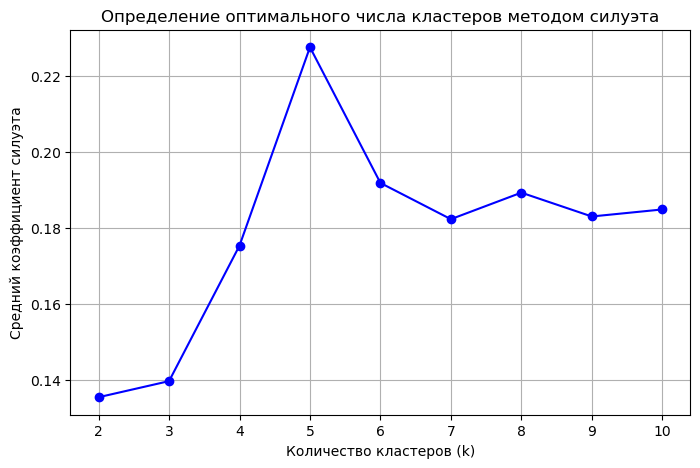

Оптимальное число кластеров: 5 со значением коэффициента силуэта 0.23


In [123]:
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    claster_labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, claster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Определение оптимального числа кластеров методом силуэта')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Средний коэффициент силуэта')
plt.grid(True)
plt.show()

# 4. Выводим лучший результат
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Оптимальное число кластеров: {best_k} со значением коэффициента силуэта {np.max(silhouette_scores):.2f}")

**Метод локтя**

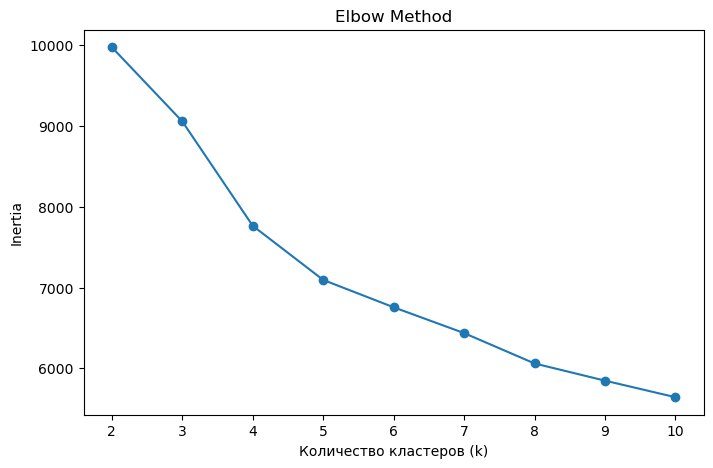

In [124]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia')
plt.show()

Оба метода для опредения оптимального числа кластеров показали, что данные не имеют четкой кластерной структуры. Коэффициент силуэта равен 0.23 при k = 5, что достаточно низко. График для метода локтя убывает плавно, нет резкого перегиба. Можно заметить небольшое замедление около k = 4-5. 

Это достаточно типично для реальных данных о людях.

Для дальнейшего анализа выбрано k = 4.

Применение метода `KMeans`

In [125]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
labels = kmeans.fit_predict(df_scaled)

df['labels'] = labels
print(df['labels'].value_counts(),'\n', experience_lvl.value_counts())

labels
1    310
3    235
0    231
2    197
Name: count, dtype: int64 
 Experience_Level
2    406
1    376
3    191
Name: count, dtype: int64


Распределение по полученным кластерам равномерное. Также количество людей в 2 кластере и с опытом 3 почти равно, возможно это одни и те же клиенты.

In [126]:
print(pd.crosstab(df['labels'], experience_lvl))

Experience_Level    1    2    3
labels                         
0                 109  101   21
1                 147  153   10
2                  23   36  138
3                  97  116   22


В кластере 2 действительно 70% клиентов продвинутые. В 1 кластере 147 новичков и 153 средних, продвинутых почти нет. Кластеры 0 и 3 очень похожи между собой, в основном новички и средние. 

Алгоритм выделил продвинутых в отдельный кластер, новичков и средних объединил в три разные группы, возможно там есть отличия, не объясняющиеся уровнем опыта.

In [127]:
df.groupby('labels').mean().round(2)

,Age,Gender,Max_BPM,Avg_BPM,Resting_BPM,Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Cardio,Workout_HIIT,Workout_Strength,Workout_Yoga
labels,,,,,,,,,,,,
0,37.56,0.54,180.31,143.93,61.77,843.03,26.71,2.53,1.00,0.00,0.00,0.00
1,40.47,0.57,180.59,141.20,62.14,780.56,27.68,2.39,0.00,0.47,0.00,0.53
2,36.50,0.19,179.56,147.57,62.53,1228.82,16.57,3.26,0.12,0.39,0.12,0.38
3,39.27,0.52,178.80,143.80,62.53,860.36,26.75,2.51,0.00,0.00,1.00,0.00


### 4.2. Кластеризация без учета типа тренировки

In [128]:
df_scaled_no_workout = df_scaled.drop(['Workout_Cardio',	'Workout_HIIT',	'Workout_Strength', 'Workout_Yoga'], axis=1)

**Метод силуэта**

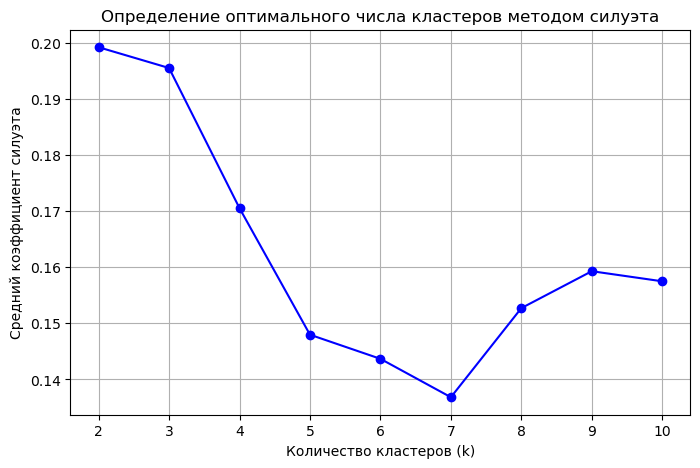

Оптимальное число кластеров: 2 со значением коэффициента силуэта 0.20


In [129]:
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    claster_labels = kmeans.fit_predict(df_scaled_no_workout)
    score = silhouette_score(df_scaled_no_workout, claster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Определение оптимального числа кластеров методом силуэта')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Средний коэффициент силуэта')
plt.grid(True)
plt.show()

# 4. Выводим лучший результат
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Оптимальное число кластеров: {best_k} со значением коэффициента силуэта {np.max(silhouette_scores):.2f}")

**Метод локтя**

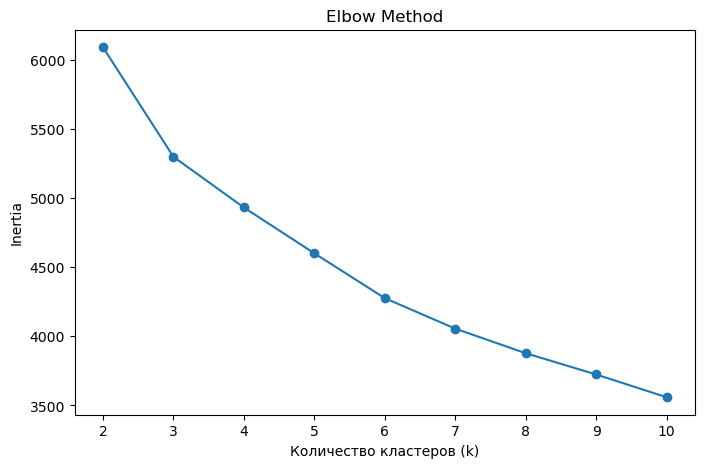

In [130]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled_no_workout)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia')
plt.show()

Результаты этого эксперимента: силуэт 0.2 при двух кластерах, линейно убывающий график в методе локтя, говорят о том, что без учета типа тренировок данные абсолютно не делятся на кластеры. Значит: тип тренировок - основное разделяющий признак в этих данных.

### 4.3. Визуализация

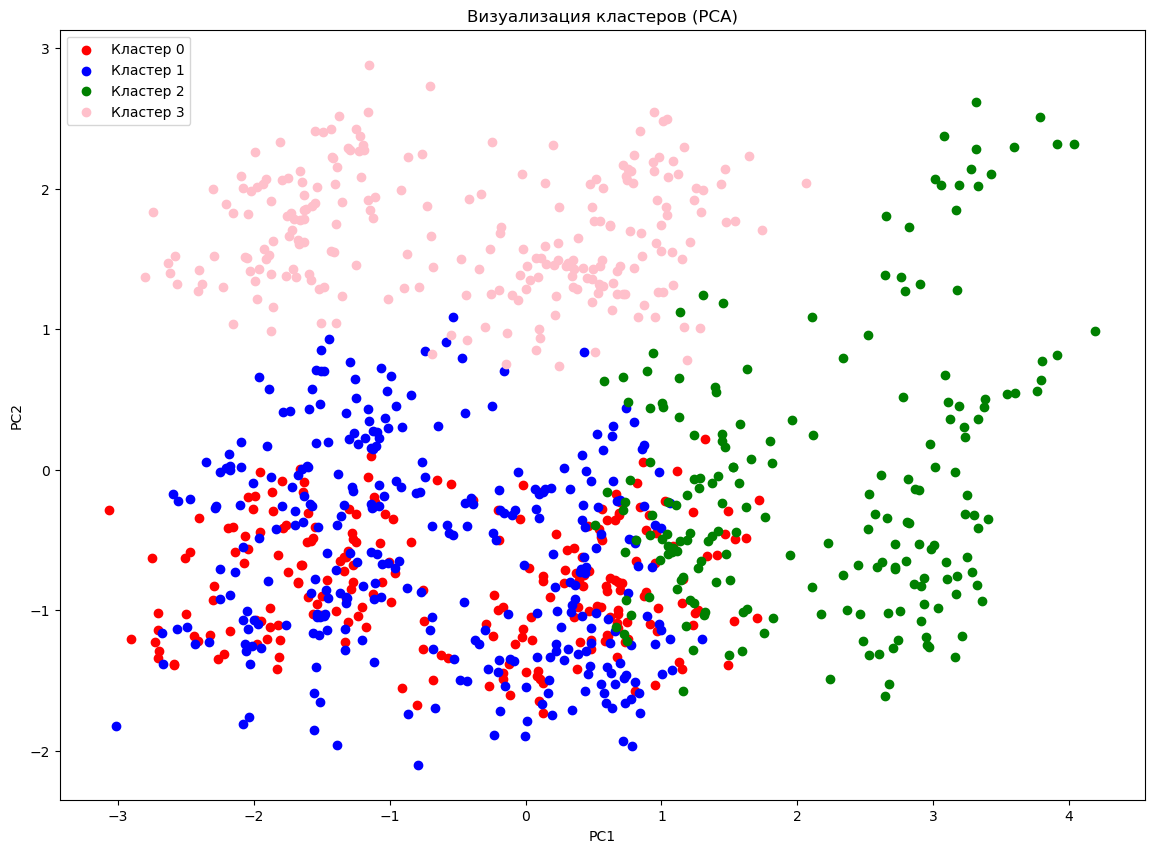

PC1: 20.3%
PC2: 11.5%


In [131]:
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(14,10))
colors = ['red','blue', 'green', 'pink']
for i in range(4):
    mask = df['labels'] == i
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1], 
                c=colors[i], label=f'Кластер {i}', alpha=1)
plt.legend()
plt.title('Визуализация кластеров (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

print(f"PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.1%}")

Первые две главные компоненты объясняют лишь 31.8% дисперсии, поэтому визуализация даёт неполную картину. Розовый (3) и зеленый (2) кластеры  хорошо отделяется даже в 2D, тогда как кластеры 0 и 1 разделены в пространстве большей размерности. Эти кластеры схожи по физиологическим показателям 
и различаются преимущественно типом тренировки — Cardio и HIIT+Yoga соответственно. В 2D-проекции они перекрываются, что отражает их реальную близость.

## 5. Выводы

В исследуемом наборе данных было выделено 4 кластера:

Кластер 0 - те, кто посещают кардио тренировки, мужчины и женщины распределены равномерно: `Gender` $= 0.54$. `Calories_Burned` $= 843.03$. 	`Fat_Percentage` $= 26.71\%$.

Кластер 1 - клиенты, посещающие и высоко интенсивные тренировки (hiit workout) и йогу. Небольшое преобладание женского пола (`Gender` $= 0.57$). Показатель `Fat_Percentage` $= 27.68\%$ выше, чем в других кластерах.

Кластер 2 - почти все клиенты - мужского пола (`Gender` $= 0.19$). Показатели `Calories_Burned` $= 1228$, `Fat_Percentage` $= 16.57\%$ и `Water_Intake (liters)` $= 3.26$ значительно отличаются от других трех кластеров. К этой группе принадлежат люди с большим опытом и лучшим уровнем физической формы. В группе преобладают интенсивные тренировки и йога.

Кластер 3 - люди, которые посещают только силовые тренировки, но по физиологическим параметрам, например `Gender` $= 0.52$. `Calories_Burned` $= 860.36$. 	`Fat_Percentage` $= 26.75\%$, 
этот кластер очень схож с кластером 0.


Анализ выявил две принципиально разные группы клиентов:
продвинутые (кластер 2) с высокими показателями активности,
и остальные три кластера, схожие по физиологии, но различающиеся
типом тренировки. Это говорит о том, что тип тренировки является
основным поведенческим выбором клиентов, тогда как физиологические
показатели определяются прежде всего уровнем опыта.


### Бизнес-рекомендации

**Кластер 2 (продвинутые)** — лояльная аудитория, 
потенциал для премиум-абонементов и персональных тренировок.

**Кластеры 0 и 1** — схожие по форме, но разные по предпочтениям. 
Можно предлагать cross-sell: кардио-клиентам пробное HIIT, и наоборот.

**Кластер 3 (силовые)** — целевая аудитория для продажи 
спортивного питания и консультаций по набору массы.